In [16]:
!pip install liac-arff seaborn matplotlib scikit-learn pandas numpy

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load data
file_path = "/content/heart_disease.csv"
df = pd.read_csv(file_path)

# Basic overview
print("Shape:", df.shape)
display(df.head())
df.info()
display(df.describe(include="all"))

Shape: (10000, 21)


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
count,9971.000000,9981,9981.000000,9970.000000,9975,9975,9979,9970,9978.000000,9974,...,9974,7414,9978,9975.000000,9970,9974.000000,9978.000000,9974.000000,9980.000000,10000
unique,NaN,2,NaN,NaN,3,2,2,2,NaN,2,...,2,3,3,NaN,3,NaN,NaN,NaN,NaN,2
top,NaN,Male,NaN,NaN,High,Yes,No,No,NaN,Yes,...,No,Medium,Medium,NaN,Low,NaN,NaN,NaN,NaN,No
freq,NaN,5003,NaN,NaN,3372,5123,5004,5018,NaN,5022,...,5036,2500,3387,NaN,3390,NaN,NaN,NaN,NaN,8000
mean,49.296259,NaN,149.757740,225.425577,NaN,NaN,NaN,NaN,29.077269,NaN,...,NaN,NaN,NaN,6.991329,NaN,250.734409,120.142213,7.472201,12.456271,NaN
std,18.193970,NaN,17.572969,43.575809,NaN,NaN,NaN,NaN,6.307098,NaN,...,NaN,NaN,NaN,1.753195,NaN,87.067226,23.584011,4.340248,4.323426,NaN
min,18.000000,NaN,120.000000,150.000000,NaN,NaN,NaN,NaN,18.002837,NaN,...,NaN,NaN,NaN,4.000605,NaN,100.000000,80.000000,0.003647,5.000236,NaN
25%,34.000000,NaN,134.000000,187.000000,NaN,NaN,NaN,NaN,23.658075,NaN,...,NaN,NaN,NaN,5.449866,NaN,176.000000,99.000000,3.674126,8.723334,NaN
50%,49.000000,NaN,150.000000,226.000000,NaN,NaN,NaN,NaN,29.079492,NaN,...,NaN,NaN,NaN,7.003252,NaN,250.000000,120.000000,7.472164,12.409395,NaN
75%,65.000000,NaN,165.000000,263.000000,NaN,NaN,NaN,NaN,34.520015,NaN,...,NaN,NaN,NaN,8.531577,NaN,326.000000,141.000000,11.255592,16.140564,NaN


In [18]:
# Missing values per column
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_percent = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({
    "Missing_Count": missing_counts,
    "Missing_%": missing_percent.round(2)
})
display(missing_df)
print("\nTotal missing values:", df.isnull().sum().sum())

,Missing_Count,Missing_%
Alcohol Consumption,2586,25.86
Diabetes,30,0.30
Sugar Consumption,30,0.30
Cholesterol Level,30,0.30
Age,29,0.29
Triglyceride Level,26,0.26
CRP Level,26,0.26
High LDL Cholesterol,26,0.26
High Blood Pressure,26,0.26
Low HDL Cholesterol,25,0.25



Total missing values: 3054


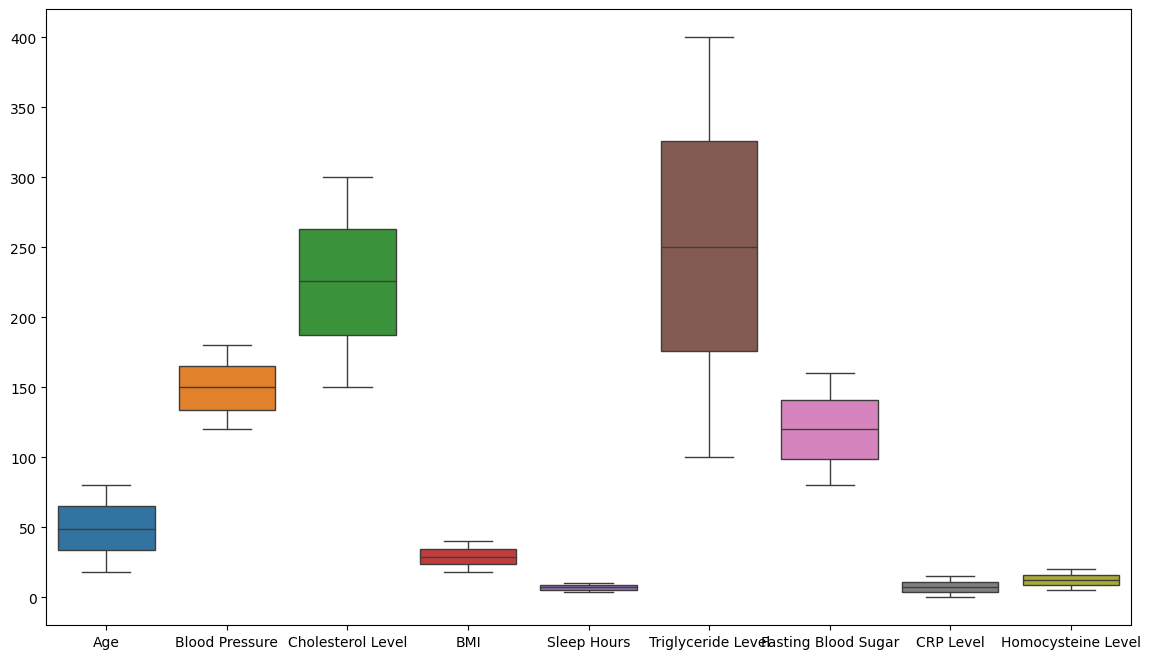

In [19]:
import seaborn as sns
plt.figure(figsize=(14,8))
sns.boxplot(df)
plt.show()

In [20]:
df_clean = df.drop_duplicates().copy()
print("Shape after dropping duplicates:", df_clean.shape)

for col in df_clean.select_dtypes(include="object").columns:
    print(f"{col}: {df_clean[col].unique()[:15]}")

cat_cols = df_clean.select_dtypes(include="object").columns

for col in cat_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.title()



Shape after dropping duplicates: (10000, 21)
Gender: ['Male' 'Female' nan]
Exercise Habits: ['High' 'Low' 'Medium' nan]
Smoking: ['Yes' 'No' nan]
Family Heart Disease: ['Yes' 'No' nan]
Diabetes: ['No' 'Yes' nan]
High Blood Pressure: ['Yes' 'No' nan]
Low HDL Cholesterol: ['Yes' 'No' nan]
High LDL Cholesterol: ['No' 'Yes' nan]
Alcohol Consumption: ['High' 'Medium' 'Low' nan]
Stress Level: ['Medium' 'High' 'Low' nan]
Sugar Consumption: ['Medium' 'Low' 'High' nan]
Heart Disease Status: ['No' 'Yes']


In [21]:
num_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df_clean.select_dtypes(include="object").columns

# Impute numeric columns with median
for col in num_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

# Impute categorical columns with mode
for col in cat_cols:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)

# Verify no missing values remain
print(df_clean.isna().sum().sum(), "missing values left in dataset")


0 missing values left in dataset


In [22]:
target_col = "Heart Disease Status"

print(df_clean[target_col].value_counts())
print(df_clean[target_col].value_counts(normalize=True) * 100)


Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64
Heart Disease Status
No     80.0
Yes    20.0
Name: proportion, dtype: float64


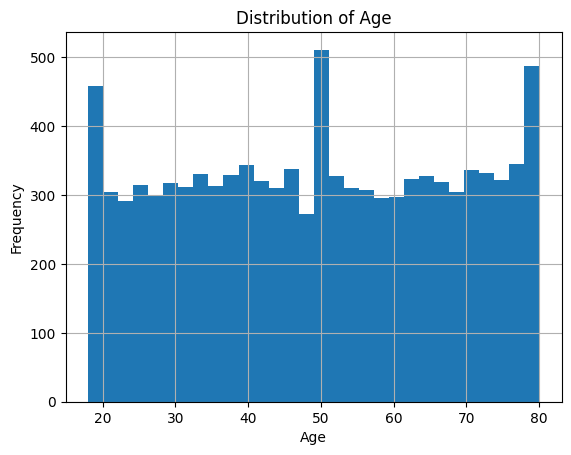

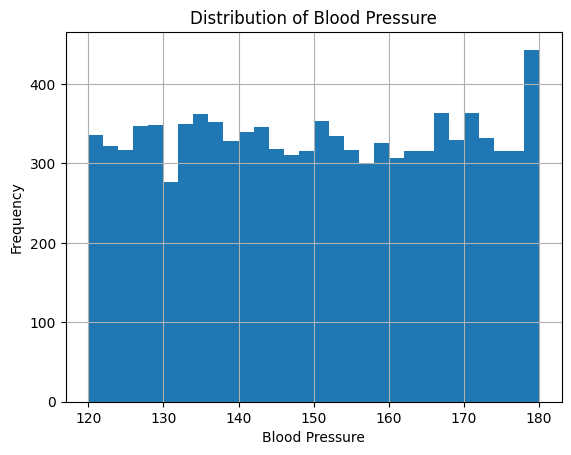

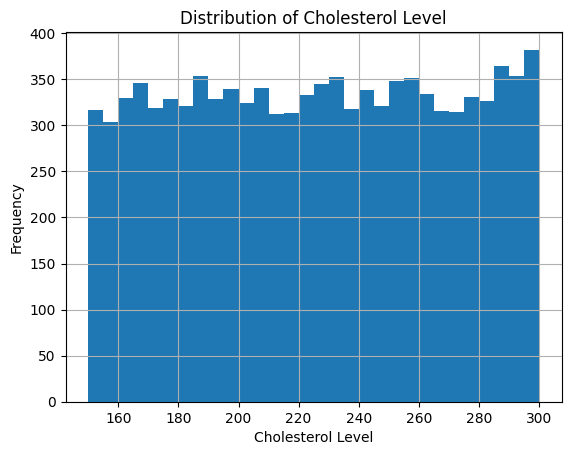

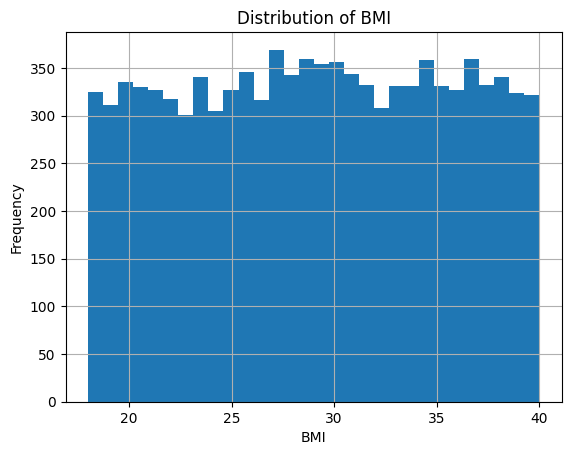

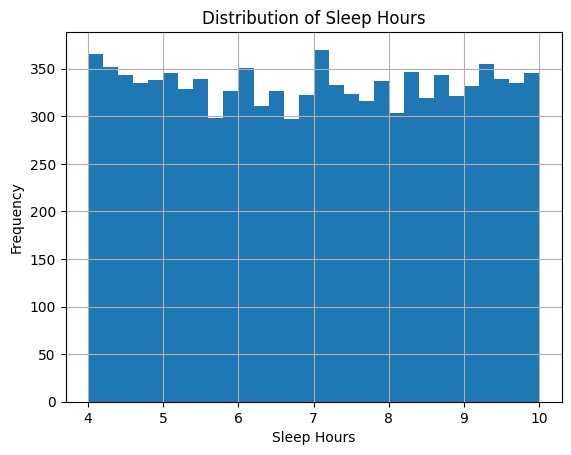

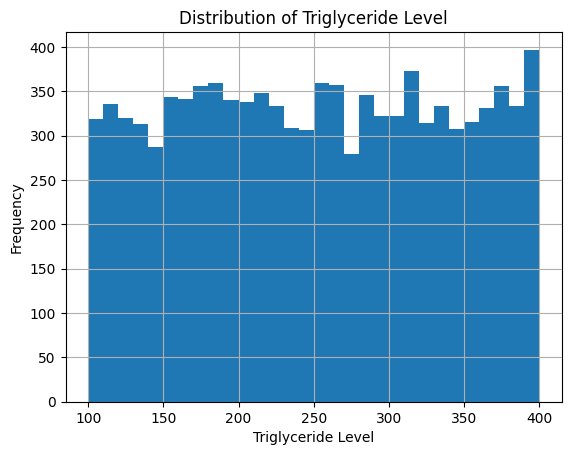

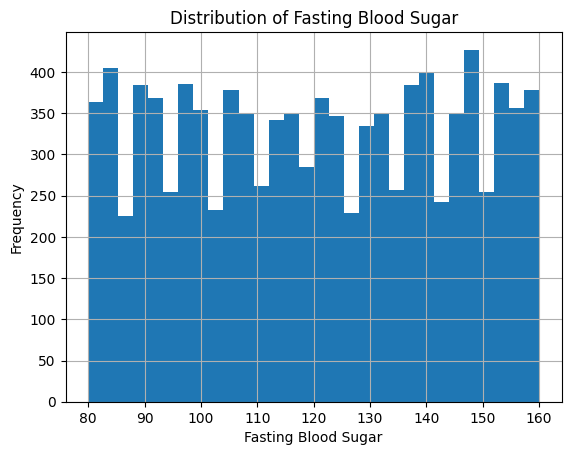

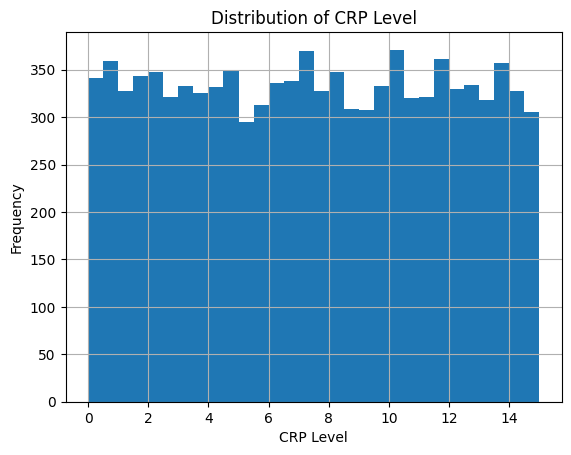

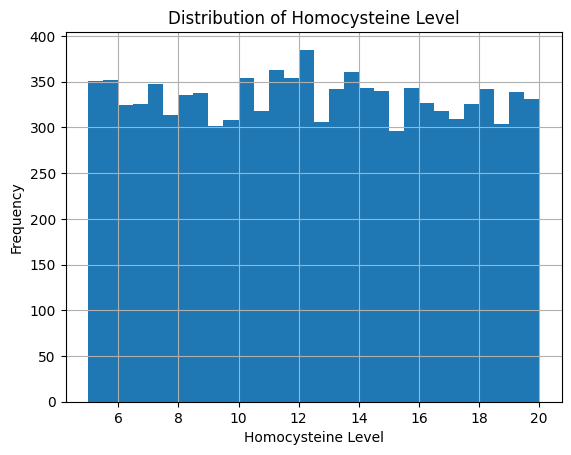


=== Gender vs Heart Disease Status ===


Heart Disease Status,No,Yes
Gender,,
Female,79.31,20.69
Male,80.63,19.37
Nan,94.74,5.26



=== Exercise Habits vs Heart Disease Status ===


Heart Disease Status,No,Yes
Exercise Habits,,
High,79.98,20.02
Low,80.28,19.72
Medium,79.62,20.38
Nan,96.00,4.00



=== Smoking vs Heart Disease Status ===


...

Heart Disease Status,No,Yes
Alcohol Consumption,,
High,79.02,20.98
Low,79.58,20.42
Medium,80.56,19.44
Nan,80.78,19.22



=== Stress Level vs Heart Disease Status ===


Heart Disease Status,No,Yes
Stress Level,,
High,80.16,19.84
Low,81.27,18.73
Medium,78.57,21.43
Nan,86.36,13.64



=== Sugar Consumption vs Heart Disease Status ===


Heart Disease Status,No,Yes
Sugar Consumption,,
High,79.40,20.60
Low,80.21,19.79
Medium,80.49,19.51
Nan,70.00,30.00


In [23]:

num_cols = [c for c in num_cols if c != target_col]

for col in num_cols:
    plt.figure()
    df_clean[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()
for col in cat_cols:
    if col == target_col:
        continue
    print(f"\n=== {col} vs {target_col} ===")
    ctab = pd.crosstab(df_clean[col], df_clean[target_col], normalize="index") * 100
    display(ctab.round(2))


In [24]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df_clean.copy()

cat_cols = df_encoded.select_dtypes(include="object").columns

encoders = {}

for c in cat_cols:
    le = LabelEncoder()
    df_encoded[c] = le.fit_transform(df_encoded[c].astype(str))
    encoders[c] = le

print("Encoded categorical columns:", list(cat_cols))
df_encoded.head()

Encoded categorical columns: ['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption', 'Heart Disease Status']


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,1,153.0,155.0,0,2,2,1,24.991591,2,...,1,0,2,7.633228,2,342.0,120.0,12.969246,12.387250,0
1,69.0,0,146.0,286.0,0,1,2,2,25.221799,1,...,1,2,0,8.744034,2,133.0,157.0,9.355389,19.298875,0
2,46.0,1,126.0,216.0,1,1,1,1,29.855447,1,...,2,1,1,4.440440,1,393.0,92.0,12.709873,11.230926,0
3,32.0,0,122.0,293.0,0,2,2,1,24.130477,2,...,2,1,0,5.249405,0,293.0,94.0,12.509046,5.961958,0
4,60.0,1,166.0,242.0,1,2,2,2,20.486289,2,...,1,1,0,7.030971,0,263.0,154.0,10.381259,8.153887,0


In [25]:
from sklearn.preprocessing import MinMaxScaler

num_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns

# Nếu target là numeric, loại target ra
target_col = "Heart Disease Status"
num_cols = [c for c in num_cols if c != target_col]

scaler = MinMaxScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

print("Scaled columns:", num_cols)
df_encoded.head()

Scaled columns: ['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sleep Hours', 'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,0.612903,0.5,0.550000,0.033333,0.000000,1.0,1.0,0.5,0.317756,1.0,...,0.5,0.000000,0.666667,0.605503,0.666667,0.806667,0.5000,0.864751,0.492507,0
1,0.822581,0.0,0.433333,0.906667,0.000000,0.5,1.0,1.0,0.328222,0.5,...,0.5,0.666667,0.000000,0.790657,0.666667,0.110000,0.9625,0.623722,0.953319,0
2,0.451613,0.5,0.100000,0.440000,0.333333,0.5,0.5,0.5,0.538899,0.5,...,1.0,0.333333,0.333333,0.073314,0.333333,0.976667,0.1500,0.847452,0.415412,0
3,0.225806,0.0,0.033333,0.953333,0.000000,1.0,1.0,0.5,0.278604,1.0,...,1.0,0.333333,0.000000,0.208156,0.000000,0.643333,0.1750,0.834058,0.064120,0
4,0.677419,0.5,0.766667,0.613333,0.333333,1.0,1.0,1.0,0.112914,1.0,...,0.5,0.333333,0.000000,0.505116,0.000000,0.543333,0.9250,0.692144,0.210260,0


In [26]:
import arff

# Chuẩn bị dữ liệu ARFF theo format liac-arff
arff_data = {
    'relation': 'heart_disease',
    'attributes': [(col, 'NUMERIC') for col in df_encoded.columns],
    'data': df_encoded.values.tolist()
}

# Ghi file
with open('heart_clean.arff', 'w') as f:
    arff.dump(arff_data, f)

print("Saved -> heart_clean.arff")


Saved -> heart_clean.arff


In [27]:
print("Final clean shape:", df_encoded.shape)

print("\nTarget distribution:")
print(df_encoded[target_col].value_counts())

print("\nTarget distribution (%):")
print((df_encoded[target_col].value_counts(normalize=True) * 100).round(2))

print("\nTop correlation with target:")
print(df_encoded.corr()[target_col].sort_values(ascending=False).head(10))


Final clean shape: (10000, 21)

Target distribution:
Heart Disease Status
0    8000
1    2000
Name: count, dtype: int64

Target distribution (%):
Heart Disease Status
0    80.0
1    20.0
Name: proportion, dtype: float64

Top correlation with target:
Heart Disease Status    1.000000
BMI                     0.019682
Stress Level            0.015526
High LDL Cholesterol    0.008711
Homocysteine Level      0.008302
Triglyceride Level      0.002904
Cholesterol Level       0.002703
High Blood Pressure     0.002375
Smoking                 0.001684
Exercise Habits         0.001212
Name: Heart Disease Status, dtype: float64
